In [3]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Load dataset (Red Wine Quality)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url,sep=";")

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
l=LinearRegression()

In [6]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1:]
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
l.fit(xtrain,ytrain)

LinearRegression()

In [8]:
s=shap.LinearExplainer(l,xtrain)

In [9]:
shap_values=s.shap_values(xtest)

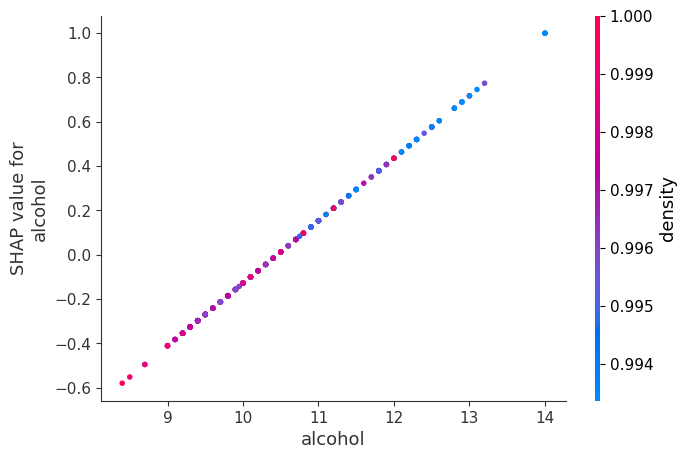

In [10]:
shap.dependence_plot("alcohol",shap_values,xtest)

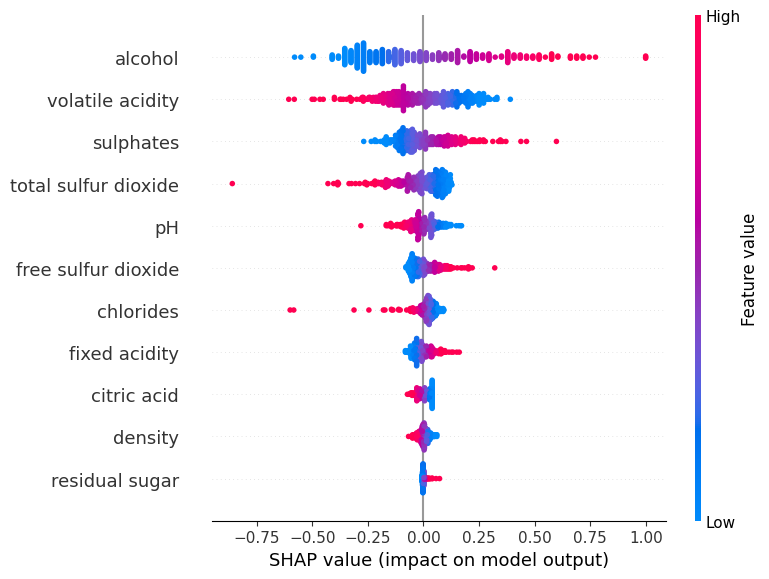

In [11]:
shap.summary_plot(shap_values,xtest)

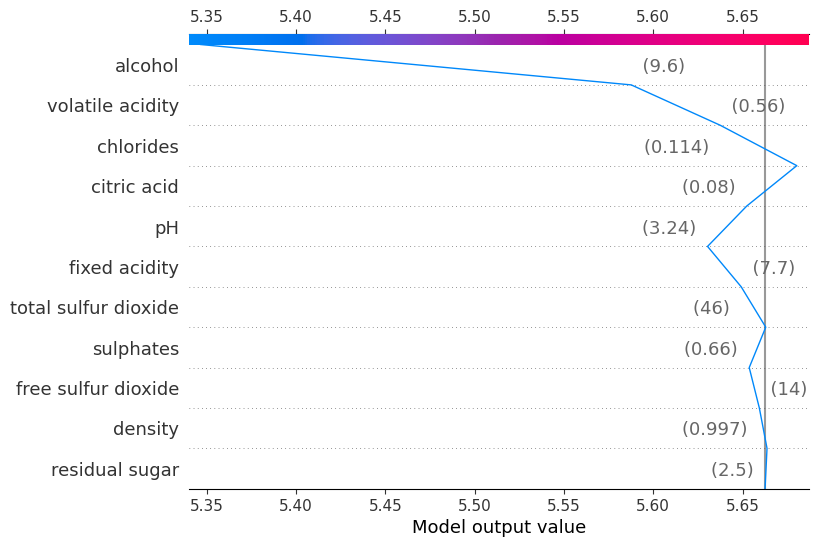

In [25]:
shap.decision_plot(s.expected_value,shap_values[0],xtest.iloc[0])